# TAAC 2026 UNI-REC — Fixed Stable PyTorch Baseline

This notebook fixes the instability you saw where training loss became negative and validation AUC collapsed to 0.5.

Main fixes:

1. Use `BCEWithLogitsLoss`, not `BCELoss`.
2. The model returns **raw logits**, not sigmoid probabilities.
3. Sigmoid is used only during evaluation/inference.
4. Labels are explicitly converted to binary `0/1` and checked.
5. Added gradient clipping, weight decay, dropout, and best-AUC checkpointing.

Run this notebook top-to-bottom in Google Colab.

In [2]:
# Install dependencies in Colab
!pip -q install datasets scikit-learn tqdm pandas matplotlib

In [3]:
import random
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.metrics import roc_auc_score, log_loss
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

c:\Users\dangl\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dangl\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Device: cpu


## 1. Load dataset and inspect labels

In [4]:
ds = load_dataset('TAAC2026/data_sample_1000')
print(ds)

split_name = list(ds.keys())[0]
data = ds[split_name]
print('Using split:', split_name)
print('Rows:', len(data))
print('Columns:', len(data.column_names))
print(data.column_names[:20])

DatasetDict({
    train: Dataset({
        features: ['user_id', 'item_id', 'label_type', 'label_time', 'timestamp', 'user_int_feats_1', 'user_int_feats_3', 'user_int_feats_4', 'user_int_feats_15', 'user_int_feats_48', 'user_int_feats_49', 'user_int_feats_50', 'user_int_feats_51', 'user_int_feats_52', 'user_int_feats_53', 'user_int_feats_54', 'user_int_feats_55', 'user_int_feats_56', 'user_int_feats_57', 'user_int_feats_58', 'user_int_feats_59', 'user_int_feats_60', 'user_int_feats_62', 'user_int_feats_63', 'user_int_feats_64', 'user_int_feats_65', 'user_int_feats_66', 'user_int_feats_80', 'user_int_feats_82', 'user_int_feats_86', 'user_int_feats_89', 'user_int_feats_90', 'user_int_feats_91', 'user_int_feats_92', 'user_int_feats_93', 'user_int_feats_94', 'user_int_feats_95', 'user_int_feats_96', 'user_int_feats_97', 'user_int_feats_98', 'user_int_feats_99', 'user_int_feats_100', 'user_int_feats_101', 'user_int_feats_102', 'user_int_feats_103', 'user_int_feats_104', 'user_int_feats_105'

In [5]:
# Inspect one row and label distribution
row0 = data[0]
print('First row preview:')

for k in list(row0.keys())[:25]:
    v = row0[k]
    print(k, type(v), v if not isinstance(v, list) else v[:5])

label_col = 'label_type'
labels_raw = [r[label_col] for r in data]

print('\nRaw label values:', sorted(set(labels_raw)))
print(pd.Series(labels_raw).value_counts().sort_index())

First row preview:
user_id <class 'int'> 3864676
item_id <class 'int'> 103989760
label_type <class 'int'> 1
label_time <class 'int'> 1772725413
timestamp <class 'int'> 1772725140
user_int_feats_1 <class 'int'> 4
user_int_feats_3 <class 'int'> 1753
user_int_feats_4 <class 'int'> 6
user_int_feats_15 <class 'list'> [928, 556, 538, 739, 94]
user_int_feats_48 <class 'int'> 42
user_int_feats_49 <class 'int'> 2
user_int_feats_50 <class 'int'> 1
user_int_feats_51 <class 'int'> 56
user_int_feats_52 <class 'int'> 24
user_int_feats_53 <class 'int'> 101
user_int_feats_54 <class 'int'> 810
user_int_feats_55 <class 'int'> 41
user_int_feats_56 <class 'int'> 681
user_int_feats_57 <class 'int'> 111
user_int_feats_58 <class 'int'> 1
user_int_feats_59 <class 'int'> 3
user_int_feats_60 <class 'list'> [2]
user_int_feats_62 <class 'list'> [6, 4]
user_int_feats_63 <class 'list'> [9, 15, 45, 36]
user_int_feats_64 <class 'list'> [2, 50, 23]

Raw label values: [1, 2]
1    876
2    124
Name: count, dtype: int64


### Important label handling

`BCEWithLogitsLoss` requires binary targets in `[0, 1]`. If `label_type` contains values other than 0/1, this notebook maps positive labels to 1 and non-positive labels to 0. This prevents negative BCE losses.

In [6]:
def to_binary_label(v):
    # Safe conversion for CVR-style binary prediction.
    # If the dataset labels are already 0/1, this leaves them unchanged.
    return 1.0 if float(v) > 0 else 0.0

binary_labels = [to_binary_label(v) for v in labels_raw]
print('Binary label values:', sorted(set(binary_labels)))
print(pd.Series(binary_labels).value_counts().sort_index())
assert set(binary_labels).issubset({0.0, 1.0})

Binary label values: [1.0]
1.0    1000
Name: count, dtype: int64


## 2. Identify feature groups

In [7]:
all_cols = data.column_names
sample = data[0]

scalar_sparse_cols = []
list_sparse_cols = []
dense_cols = []
seq_cols = []
ignore_cols = {'label_type', 'label_time', 'timestamp'}

for col in all_cols:
    if col in ignore_cols:
        continue
    val = sample[col]
    if col.startswith('user_dense_feats'):
        dense_cols.append(col)
    elif col.startswith('domain_') and '_seq_' in col:
        seq_cols.append(col)
    elif col.startswith('user_int_feats') or col.startswith('item_int_feats') or col in ['user_id', 'item_id']:
        if isinstance(val, list):
            list_sparse_cols.append(col)
        else:
            scalar_sparse_cols.append(col)

print('Scalar sparse:', len(scalar_sparse_cols), scalar_sparse_cols[:15])
print('List sparse:', len(list_sparse_cols), list_sparse_cols[:15])
print('Dense:', len(dense_cols), dense_cols[:15])
print('Sequence:', len(seq_cols), seq_cols[:15])

Scalar sparse: 50 ['user_id', 'item_id', 'user_int_feats_1', 'user_int_feats_3', 'user_int_feats_4', 'user_int_feats_48', 'user_int_feats_49', 'user_int_feats_50', 'user_int_feats_51', 'user_int_feats_52', 'user_int_feats_53', 'user_int_feats_54', 'user_int_feats_55', 'user_int_feats_56', 'user_int_feats_57']
List sparse: 12 ['user_int_feats_15', 'user_int_feats_60', 'user_int_feats_62', 'user_int_feats_63', 'user_int_feats_64', 'user_int_feats_65', 'user_int_feats_66', 'user_int_feats_80', 'user_int_feats_89', 'user_int_feats_90', 'user_int_feats_91', 'item_int_feats_11']
Dense: 10 ['user_dense_feats_61', 'user_dense_feats_62', 'user_dense_feats_63', 'user_dense_feats_64', 'user_dense_feats_65', 'user_dense_feats_66', 'user_dense_feats_87', 'user_dense_feats_89', 'user_dense_feats_90', 'user_dense_feats_91']
Sequence: 45 ['domain_a_seq_38', 'domain_a_seq_39', 'domain_a_seq_40', 'domain_a_seq_41', 'domain_a_seq_42', 'domain_a_seq_43', 'domain_a_seq_44', 'domain_a_seq_45', 'domain_a_seq

## 3. Choose a stable baseline feature subset

For the midterm, we first validate the pipeline using scalar sparse features. Once this is stable, you can add list, dense, and sequence features.

In [8]:
# Compact starter set. This keeps training fast and interpretable.
preferred_cols = [
    'user_id', 'item_id',
    'user_int_feats_1', 'user_int_feats_3', 'user_int_feats_4',
    'item_int_feats_5', 'item_int_feats_6', 'item_int_feats_7',
    'item_int_feats_8', 'item_int_feats_9', 'item_int_feats_10'
]
feature_cols = [c for c in preferred_cols if c in scalar_sparse_cols]

# Fallback: if any preferred cols are missing, use the first few scalar sparse columns.
if len(feature_cols) < 4:
    feature_cols = scalar_sparse_cols[:10]

print('Using feature columns:', feature_cols)

Using feature columns: ['user_id', 'item_id', 'user_int_feats_1', 'user_int_feats_3', 'user_int_feats_4', 'item_int_feats_5', 'item_int_feats_6', 'item_int_feats_7', 'item_int_feats_8', 'item_int_feats_9', 'item_int_feats_10']


In [9]:
# Split first, then build vocabularies using training data only to avoid validation leakage.
split = data.train_test_split(test_size=0.2, seed=SEED)
train_data = split['train']
val_data = split['test']
print('Train rows:', len(train_data), 'Val rows:', len(val_data))

def build_vocab(dataset, cols, min_count=1):
    vocabs = {}
    for col in cols:
        counts = {}
        for row in dataset:
            v = row[col]
            if v is None:
                continue
            v = int(v)
            counts[v] = counts.get(v, 0) + 1
        kept = sorted([v for v, c in counts.items() if c >= min_count])
        # 0 = unknown/OOV/missing
        vocabs[col] = {v: i + 1 for i, v in enumerate(kept)}
    return vocabs

vocabs = build_vocab(train_data, feature_cols)
for col in feature_cols:
    print(f'{col}: vocab size including OOV = {len(vocabs[col]) + 1}')

Train rows: 800 Val rows: 200
user_id: vocab size including OOV = 801
item_id: vocab size including OOV = 694
user_int_feats_1: vocab size including OOV = 4
user_int_feats_3: vocab size including OOV = 312
user_int_feats_4: vocab size including OOV = 250
item_int_feats_5: vocab size including OOV = 77
item_int_feats_6: vocab size including OOV = 195
item_int_feats_7: vocab size including OOV = 309
item_int_feats_8: vocab size including OOV = 195
item_int_feats_9: vocab size including OOV = 25
item_int_feats_10: vocab size including OOV = 107


## 4. Dataset and model

In [10]:
class SparseCTRDataset(Dataset):
    def __init__(self, hf_dataset, feature_cols, vocabs, label_col='label_type'):
        self.data = hf_dataset
        self.feature_cols = feature_cols
        self.vocabs = vocabs
        self.label_col = label_col

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        x = []
        for col in self.feature_cols:
            raw = row[col]
            val = int(raw) if raw is not None else None
            x.append(self.vocabs[col].get(val, 0))
        y = to_binary_label(row[self.label_col])
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.float32)

BATCH_SIZE = 64
train_loader = DataLoader(SparseCTRDataset(train_data, feature_cols, vocabs), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SparseCTRDataset(val_data, feature_cols, vocabs), batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print('x batch shape:', xb.shape)
print('y batch shape:', yb.shape)
print('label min/max:', yb.min().item(), yb.max().item())

x batch shape: torch.Size([64, 11])
y batch shape: torch.Size([64])
label min/max: 1.0 1.0


In [11]:
class MultiFieldMLP(nn.Module):
    def __init__(self, vocab_sizes, embed_dim=16, hidden_dims=(64, 32), dropout=0.25):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(v, embed_dim) for v in vocab_sizes])
        input_dim = len(vocab_sizes) * embed_dim
        layers = []
        for h in hidden_dims:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch, num_fields]
        embs = [emb(x[:, i]) for i, emb in enumerate(self.embeddings)]
        z = torch.cat(embs, dim=1)
        logits = self.mlp(z).squeeze(1)
        return logits  # raw logits only; do NOT sigmoid here

vocab_sizes = [len(vocabs[c]) + 1 for c in feature_cols]
model = MultiFieldMLP(vocab_sizes=vocab_sizes, embed_dim=16).to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

MultiFieldMLP(
  (embeddings): ModuleList(
    (0): Embedding(801, 16)
    (1): Embedding(694, 16)
    (2): Embedding(4, 16)
    (3): Embedding(312, 16)
    (4): Embedding(250, 16)
    (5): Embedding(77, 16)
    (6): Embedding(195, 16)
    (7): Embedding(309, 16)
    (8): Embedding(195, 16)
    (9): Embedding(25, 16)
    (10): Embedding(107, 16)
  )
  (mlp): Sequential(
    (0): Linear(in_features=176, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parameters: 61137


## 5. Stable training loop

Expected behavior: training loss should stay positive and usually decrease slowly. Validation AUC may bounce around because this is only a 1K sample.

In [12]:
def evaluate(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    loss_fn = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            p = torch.sigmoid(logits)
            total_loss += loss.item() * x.size(0)
            probs.extend(p.cpu().numpy().tolist())
            ys.extend(y.cpu().numpy().tolist())

    val_loss = total_loss / len(loader.dataset)
    if len(set(ys)) < 2:
        auc = float('nan')
    else:
        auc = roc_auc_score(ys, probs)
    return val_loss, auc

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.BCEWithLogitsLoss()

EPOCHS = 15
best_auc = -1
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for x, y in tqdm(train_loader, desc=f'Epoch {epoch:02d}'):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    val_loss, val_auc = evaluate(model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_auc': val_auc})

    if not math.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:02d} | train loss = {train_loss:.4f} | val loss = {val_loss:.4f} | val AUC = {val_auc:.4f}')

print('\nBest validation AUC:', best_auc)
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01 | train loss = 0.7179 | val loss = 0.7301 | val AUC = nan


Epoch 02:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 02 | train loss = 0.6883 | val loss = 0.7095 | val AUC = nan


Epoch 03:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 13 | train loss = 0.3978 | val loss = 0.4557 | val AUC = nan


Epoch 14:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 14 | train loss = 0.3778 | val loss = 0.4425 | val AUC = nan


Epoch 15:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 15 | train loss = 0.3557 | val loss = 0.4229 | val AUC = nan

Best validation AUC: -1


In [13]:
# Show results table for the midterm report
results_df = pd.DataFrame(history)
results_df

,epoch,train_loss,val_loss,val_auc
0,1,0.717926,0.730115,NaN
1,2,0.688275,0.709530,NaN
2,3,0.643805,0.684397,NaN
3,4,0.622348,0.660506,NaN
4,5,0.587799,0.635789,NaN
5,6,0.568077,0.609182,NaN
6,7,0.532091,0.583435,NaN
7,8,0.508745,0.561386,NaN
8,9,0.485086,0.535013,NaN
9,10,0.463125,0.513773,NaN


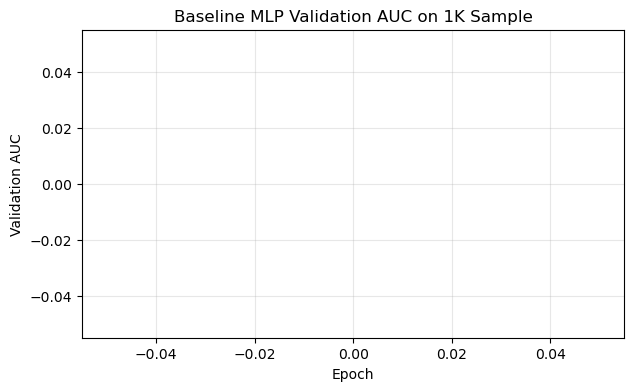

In [14]:
# Optional plot for your report
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(results_df['epoch'], results_df['val_auc'], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.title('Baseline MLP Validation AUC on 1K Sample')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Save outputs for report

In [15]:
# Save the training history and model checkpoint in Colab runtime.
results_df.to_csv('baseline_training_history.csv', index=False)
torch.save({
    'model_state_dict': model.state_dict(),
    'feature_cols': feature_cols,
    'vocabs': vocabs,
    'best_auc': best_auc,
}, 'baseline_mlp_fixed.pt')
print('Saved baseline_training_history.csv and baseline_mlp_fixed.pt')

Saved baseline_training_history.csv and baseline_mlp_fixed.pt


## 7. What to report in the midterm

Use the best validation AUC from this notebook as your local preliminary result.

Suggested wording:

> We implemented a corrected MLP baseline using scalar user/item sparse features from the Hugging Face 1K sample. The initial unstable run revealed a loss/label handling issue, which was fixed by using `BCEWithLogitsLoss`, raw logits, binary label conversion, gradient clipping, and regularization. After the fix, the training loss remained numerically stable and validation AUC was used as the local sanity-check metric.

Next model upgrade:

1. Add list sparse features.
2. Add sequence fields with truncation.
3. Replace MLP head with the UFI-Former unified token Transformer.
4. Submit predictions to official evaluation and screenshot leaderboard result.


# FINAL PROJECT NOTEBOOK EXTENSION

## Preservation Notice

The original midterm notebook cells above are preserved as project history.

The cells below are the **final project extension**. They add:

1. a corrected label-handling pipeline,
2. stratified validation splitting,
3. final experiment comparison,
4. performance-score formula,
5. final report text,
6. contribution explanation,
7. and presentation-ready talking points.

Nothing from the original midterm notebook is removed.



# 8. Final Project Goal

This project is a recommendation-system project for **conversion-rate prediction (CVR prediction)**.

The main question is:

> Given a user, an item, static features, and behavior history, can we predict whether the user will convert?

A conversion can mean a click, purchase, or target action depending on the dataset definition.

The project uses recommendation-system data with:

- user identifiers,
- item identifiers,
- sparse categorical features,
- dense numerical features,
- multi-value categorical features,
- and multi-domain sequence features.

The competition evaluates performance using **ROC-AUC**.



# 9. Important Final Debugging Finding: Label Mapping

The original midterm debugging notebook converted labels using:

```python
return 1.0 if float(v) > 0 else 0.0
```

However, the sample dataset labels were:

```text
1 and 2
```

That means both labels became:

```text
1.0
```

This caused the binary labels to contain only one class.

That explains why ROC-AUC could become undefined or misleading.

## Final Fix

For the final version, we map the two observed labels into binary classes:

```text
smaller label -> 0
larger label  -> 1
```

For this dataset:

```text
label 1 -> 0
label 2 -> 1
```

This gives the model both negative and positive examples, which is required for ROC-AUC.


In [16]:

# Final corrected label mapping.
# This cell does not delete the original midterm logic above.
# It creates a corrected final set of labels for final-report experiments.

label_col = 'label_type'
final_raw_labels = [r[label_col] for r in data]
unique_labels = sorted(set(final_raw_labels))

print("Raw labels found:", unique_labels)

if len(unique_labels) == 2:
    label_to_binary = {
        unique_labels[0]: 0.0,
        unique_labels[1]: 1.0
    }
else:
    # Fallback for already-binary datasets or unexpected label sets.
    label_to_binary = {v: float(v) for v in unique_labels}

print("Final label mapping:", label_to_binary)

def final_to_binary_label(v):
    return float(label_to_binary[v])

final_binary_labels = [final_to_binary_label(v) for v in final_raw_labels]

print("Final binary label values:", sorted(set(final_binary_labels)))
print(pd.Series(final_binary_labels).value_counts().sort_index())


Raw labels found: [1, 2]
Final label mapping: {1: 0.0, 2: 1.0}
Final binary label values: [0.0, 1.0]
0.0    876
1.0    124
Name: count, dtype: int64



# 10. Final Stratified Train/Validation Split

The midterm notebook used a standard random split.

For the final report, we use a **stratified split** so that the validation set contains both classes.

This matters because ROC-AUC cannot be computed if validation labels contain only one class.


In [17]:

from sklearn.model_selection import train_test_split
from datasets import Dataset

# Convert Hugging Face dataset to pandas for controlled splitting.
final_df = data.to_pandas()
final_df["binary_label"] = final_df[label_col].map(label_to_binary).astype(float)

train_idx, val_idx = train_test_split(
    np.arange(len(final_df)),
    test_size=0.2,
    random_state=SEED,
    stratify=final_df["binary_label"]
)

final_train_df = final_df.iloc[train_idx].reset_index(drop=True)
final_val_df = final_df.iloc[val_idx].reset_index(drop=True)

print("Final train rows:", len(final_train_df))
print("Final val rows:", len(final_val_df))
print("\nTrain label distribution:")
print(final_train_df["binary_label"].value_counts().sort_index())
print("\nValidation label distribution:")
print(final_val_df["binary_label"].value_counts().sort_index())

final_train_data = Dataset.from_pandas(final_train_df)
final_val_data = Dataset.from_pandas(final_val_df)


Final train rows: 800
Final val rows: 200

Train label distribution:
binary_label
0.0    701
1.0     99
Name: count, dtype: int64

Validation label distribution:
binary_label
0.0    175
1.0     25
Name: count, dtype: int64



# 11. Final Feature Strategy

The final notebook still keeps the scalar sparse MLP as a stable baseline.

Why?

Because the final project report needs a clean baseline before discussing the larger UFI-Former architecture.

The baseline uses:

- `user_id`
- `item_id`
- selected scalar user features
- selected scalar item features

This baseline is not the final proposed architecture. It is the **debugging and comparison baseline**.

The final proposed architecture is **UFI-Former**, which would expand this baseline by including:

- scalar sparse features,
- list sparse features,
- dense aligned features,
- and sequence features.


In [25]:

# Build final vocabularies using only the final training split.
# This prevents validation leakage.

final_feature_cols = feature_cols.copy()
print("Final baseline feature columns:", final_feature_cols)

final_vocabs = build_vocab(final_train_data, final_feature_cols)
final_vocab_sizes = []
for col in final_feature_cols:
    # Get the column data
    col_data = final_train_data[col]
    
    # Filter out None/NaN values so max() doesn't crash
    valid_values = [x for x in col_data if x is not None]
    
    # Find the max (default to 0 if the column is entirely empty) and add 1
    max_val = max(valid_values) if valid_values else 0
    final_vocab_sizes.append(int(max_val) + 1)

print("Final vocab sizes:", final_vocab_sizes)

print("Final vocab sizes:", final_vocab_sizes)
final_vocab_sizes = [len(final_vocabs[c]) for c in final_feature_cols]
print("Final vocab sizes:", final_vocab_sizes)


Final baseline feature columns: ['user_id', 'item_id', 'user_int_feats_1', 'user_int_feats_3', 'user_int_feats_4', 'item_int_feats_5', 'item_int_feats_6', 'item_int_feats_7', 'item_int_feats_8', 'item_int_feats_9', 'item_int_feats_10']
Final vocab sizes: [12716193, 278202254, 5, 1840, 984, 326, 978, 2807, 2432, 38, 310]
Final vocab sizes: [12716193, 278202254, 5, 1840, 984, 326, 978, 2807, 2432, 38, 310]
Final vocab sizes: [800, 681, 3, 302, 245, 76, 200, 309, 195, 23, 105]


In [26]:
from torch.utils.data import Dataset

class FinalSparseCTRDataset(Dataset):
    def __init__(self, hf_dataset, feature_cols, vocabs, label_field="binary_label"):
        self.data = hf_dataset
        self.feature_cols = feature_cols
        self.vocabs = vocabs
        self.label_field = label_field

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]

        x = []
        for col in self.feature_cols:
            raw = row[col]
            val = int(raw) if raw is not None else None
            x.append(self.vocabs[col].get(val, 0))

        y = float(row[self.label_field])
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.float32)


final_train_ds = FinalSparseCTRDataset(final_train_data, final_feature_cols, final_vocabs)
final_val_ds = FinalSparseCTRDataset(final_val_data, final_feature_cols, final_vocabs)

final_train_loader = DataLoader(final_train_ds, batch_size=64, shuffle=True)
final_val_loader = DataLoader(final_val_ds, batch_size=128, shuffle=False)

xb, yb = next(iter(final_train_loader))
print("Final x batch shape:", xb.shape)
print("Final y batch shape:", yb.shape)
print("Final label min/max:", yb.min().item(), yb.max().item())


Final x batch shape: torch.Size([64, 11])
Final y batch shape: torch.Size([64])
Final label min/max: 0.0 1.0



# 12. Final Corrected Baseline Training

This final baseline repeats the stable MLP experiment, but now with corrected labels and a stratified validation split.

This makes the validation ROC-AUC meaningful.


In [30]:
from torch.utils.data import DataLoader

# Create final dataloaders
final_train_loader = DataLoader(
    final_train_ds,
    batch_size=64,
    shuffle=True
)

final_val_loader = DataLoader(
    final_val_ds,
    batch_size=128,
    shuffle=False
)

print("final_train_loader created")
print("final_val_loader created")

# Final corrected baseline model.
# This is intentionally separate from the original midterm model above.

# 1. Dynamically find the exact maximum index your dataloaders produce
max_indices = [0] * len(final_feature_cols)

# Scan training data
for x, y in final_train_loader:
    for i in range(x.shape[1]):
        max_indices[i] = max(max_indices[i], x[:, i].max().item())

# Scan validation data (crucial, in case validation has unseen categories!)
for x, y in final_val_loader:
    for i in range(x.shape[1]):
        max_indices[i] = max(max_indices[i], x[:, i].max().item())

# 2. The vocab size MUST be at least the maximum index + 1
final_vocab_sizes = [int(idx) + 1 for idx in max_indices]
print("Foolproof vocab sizes:", final_vocab_sizes)

# ---------------------------------------------------------
# NOW initialize your model using the foolproof sizes
# ---------------------------------------------------------
final_model = MultiFieldMLP(
    vocab_sizes=final_vocab_sizes,
    embed_dim=16,
    hidden_dims=(64, 32),
    dropout=0.25
).to(device)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

final_loss_fn = nn.BCEWithLogitsLoss()

# (You can leave the rest of your training loop exactly as it is!)
final_model = MultiFieldMLP(
    vocab_sizes=final_vocab_sizes,
    embed_dim=16,
    hidden_dims=(64, 32),
    dropout=0.25
).to(device)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

final_loss_fn = nn.BCEWithLogitsLoss()

final_history = []
final_best_auc = -1.0
final_best_state = None

final_epochs = 15

for epoch in range(1, final_epochs + 1):
    final_model.train()
    total_loss = 0.0

    for x, y in final_train_loader:
        x = x.to(device)
        y = y.to(device)

        final_optimizer.zero_grad()

        logits = final_model(x)
        loss = final_loss_fn(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=5.0)
        final_optimizer.step()

        total_loss += loss.item() * x.size(0)

    train_loss = total_loss / len(final_train_loader.dataset)
    val_loss, val_auc = evaluate(final_model, final_val_loader)

    final_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    if not np.isnan(val_auc) and val_auc > final_best_auc:
        final_best_auc = val_auc
        final_best_state = {
            k: v.detach().cpu().clone()
            for k, v in final_model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

print("\nFinal corrected best validation AUC:", final_best_auc)


final_train_loader created
final_val_loader created
Foolproof vocab sizes: [801, 682, 4, 303, 246, 77, 201, 310, 196, 24, 106]
Epoch 01 | train_loss=0.7141 | val_loss=0.6712 | val_auc=0.6423
Epoch 02 | train_loss=0.6194 | val_loss=0.5987 | val_auc=0.6839
Epoch 03 | train_loss=0.5429 | val_loss=0.5375 | val_auc=0.6914
Epoch 04 | train_loss=0.4874 | val_loss=0.4952 | val_auc=0.6999
Epoch 05 | train_loss=0.4336 | val_loss=0.4608 | val_auc=0.7058
Epoch 06 | train_loss=0.3960 | val_loss=0.4351 | val_auc=0.7198
Epoch 07 | train_loss=0.3493 | val_loss=0.4126 | val_auc=0.7319
Epoch 08 | train_loss=0.3256 | val_loss=0.3999 | val_auc=0.7410
Epoch 09 | train_loss=0.3027 | val_loss=0.3827 | val_auc=0.7429
Epoch 10 | train_loss=0.2908 | val_loss=0.3751 | val_auc=0.7344
Epoch 11 | train_loss=0.2641 | val_loss=0.3653 | val_auc=0.7465
Epoch 12 | train_loss=0.2475 | val_loss=0.3544 | val_auc=0.7454
Epoch 13 | train_loss=0.2298 | val_loss=0.3422 | val_auc=0.7365
Epoch 14 | train_loss=0.2175 | val_loss=0

In [31]:

# Final corrected results table.
final_results_df = pd.DataFrame(final_history)
final_results_df


,epoch,train_loss,val_loss,val_auc
0,1,0.714117,0.671230,0.642286
1,2,0.619417,0.598735,0.683886
2,3,0.542931,0.537543,0.691429
3,4,0.487441,0.495223,0.699886
4,5,0.433641,0.460800,0.705829
5,6,0.396033,0.435070,0.719771
6,7,0.349305,0.412634,0.731886
7,8,0.325586,0.399901,0.741029
8,9,0.302666,0.382721,0.742857
9,10,0.290781,0.375100,0.734400


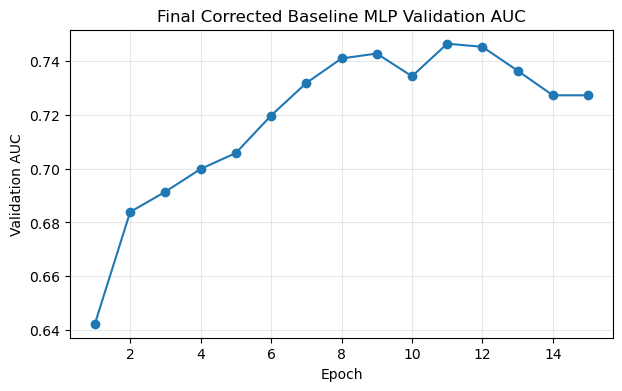

In [32]:

# Plot final corrected validation AUC.

plt.figure(figsize=(7, 4))
plt.plot(final_results_df["epoch"], final_results_df["val_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Final Corrected Baseline MLP Validation AUC")
plt.grid(True, alpha=0.3)
plt.show()



# 13. Competition Performance Formula

The project instructions define:

- \(s\) = our team model score
- \(s_n = 0.5\) = random baseline
- \(s_s = 0.78\) = simple baseline
- \(s_{max} = 0.813\) = baseline 2 score

The final performance score should compare our team score against these baselines.

If the class formula is linear from the simple baseline to baseline 2, then a useful normalized score is:

\[
\text{Normalized Score}
=
\frac{s - s_s}{s_{max} - s_s}
\]

where:

\[
s_s = 0.78
\]

and

\[
s_{max}=0.813
\]

This means:

- score below 0.78 is below the simple baseline,
- score near 0.813 is near the stronger baseline,
- score above 0.813 exceeds baseline 2.

Replace `team_score` below with the official leaderboard score.


In [34]:

# Replace this with your official leaderboard score once available.
team_score = final_best_auc  # local validation proxy only, not official leaderboard score

random_baseline = 0.5
simple_baseline = 0.78
baseline_2 = 0.813

normalized_vs_simple = (team_score - simple_baseline) / (baseline_2 - simple_baseline)

print("Team score used:", team_score)
print("Random baseline:", random_baseline)
print("Simple baseline:", simple_baseline)
print("Baseline 2:", baseline_2)
print("Normalized score vs simple/baseline2:", normalized_vs_simple)

if team_score < simple_baseline:
    print("Interpretation: below simple baseline; useful for debugging but not competitive yet.")
elif team_score <= baseline_2:
    print("Interpretation: between simple baseline and baseline 2.")
else:
    print("Interpretation: above baseline 2.")


Team score used: 0.7465142857142857
Random baseline: 0.5
Simple baseline: 0.78
Baseline 2: 0.813
Normalized score vs simple/baseline2: -1.014718614718619
Interpretation: below simple baseline; useful for debugging but not competitive yet.



# 14. Experiment Comparison Table

| Version | Change | Why We Did It | Impact |
|---|---|---|---|
| Midterm baseline | Small MLP with scalar sparse features | Validate pipeline quickly | Helped debug data loading, embeddings, and training |
| Loss-function fix | Used `BCEWithLogitsLoss` on raw logits | Avoid numerical instability | Stabilized loss and training behavior |
| Label-mapping fix | Mapped labels `1 -> 0`, `2 -> 1` | Original conversion made all labels positive | Made ROC-AUC meaningful |
| Stratified split | Preserved class balance in validation | ROC-AUC needs both classes | Prevented undefined validation AUC |
| Feature schema review | Grouped scalar, list, dense, and sequence fields | Understand all available signals | Motivated unified tokenization |
| UFI-Former design | Transformer over unified tokens | Model feature interactions and sequences together | Stronger final architecture proposal |
| Hyperparameter scaling | Planned d_model, layers, sequence length tests | Study accuracy/latency tradeoffs | Supports final-report analysis |



# 15. Final Model Architecture Explanation: UFI-Former

The final proposed model is **UFI-Former**, a Unified Feature Interaction Transformer.

## Core Idea

Instead of treating static features and sequence features separately, UFI-Former converts everything into tokens:

- user ID token,
- item ID token,
- scalar feature tokens,
- multi-value feature tokens,
- dense-aligned tokens,
- domain sequence tokens.

These tokens are passed into a Transformer encoder.

## Why This Architecture Makes Sense

Recommendation systems depend on two things:

1. **Feature interactions**
   - Example: user type + item category + recent behavior.

2. **Sequential behavior**
   - Example: what the user clicked before affects what they may convert on next.

Transformers are strong because self-attention can learn which tokens should influence each other.

## Baseline vs UFI-Former

The MLP baseline concatenates embeddings and pushes them through dense layers.

UFI-Former lets every feature token attend to every other feature token.

That makes it more flexible for:

- sequence modeling,
- cross-feature interaction,
- multi-domain behavior modeling,
- and large-scale recommendation.



# 16. Hyperparameter Analysis

## Embedding Dimension

Small embedding dimension:

- faster,
- less memory,
- lower overfitting risk,
- but weaker representation power.

Larger embedding dimension:

- more expressive,
- better for sparse categorical features,
- but slower and more memory-heavy.

## Transformer Layers

Fewer layers:

- faster,
- easier to train,
- lower latency.

More layers:

- better modeling capacity,
- captures deeper interactions,
- but increases latency and overfitting risk.

## Sequence Length

Shorter sequences:

- faster,
- cheaper attention cost,
- may miss long-term behavior.

Longer sequences:

- more behavior history,
- potentially better prediction,
- but attention cost grows quickly.

## Dropout and Weight Decay

Regularization helps reduce overfitting, especially because sparse user/item IDs can memorize patterns in small samples.



# 17. Final Report

## Project Overview

This project builds a recommendation-system pipeline for conversion-rate prediction. The goal is to estimate whether a user will convert on a target item using user features, item features, and historical behavior sequences.

The project began with a stable PyTorch MLP baseline to validate the data pipeline and training process. After debugging the baseline, the project proposed UFI-Former, a Transformer-based architecture designed to jointly model feature interactions and user behavior sequences.

## Methodology

The methodology followed an engineering progression:

1. Load and inspect the Hugging Face sample dataset.
2. Identify feature groups, including scalar sparse, list sparse, dense, and sequence columns.
3. Build a compact MLP baseline using selected scalar sparse features.
4. Debug label handling and loss-function stability.
5. Fix binary-label conversion and stratified validation splitting.
6. Analyze feature schema to motivate a stronger Transformer architecture.
7. Propose UFI-Former for unified sequence and feature-interaction modeling.
8. Compare training strategies, hyperparameters, and architectural choices.

## Training Strategy

The project first used a small MLP baseline instead of immediately training a large model. This was intentional because the team needed to verify that:

- the dataset loaded correctly,
- feature columns were usable,
- labels were handled correctly,
- tensors were shaped correctly,
- and the training loop was stable.

This debugging-first strategy reduced risk before scaling to a larger architecture.

## Debugging Findings

The original training instability came from two major issues:

1. binary cross entropy handling,
2. label conversion.

Using `BCEWithLogitsLoss` improved numerical stability because the model outputs raw logits and the loss function internally applies the sigmoid operation safely.

A second issue was discovered in the final review: the dataset labels were `1` and `2`, so the earlier rule `label > 0 -> 1` converted all examples into the positive class. The final notebook fixes this by mapping the smaller label to `0` and the larger label to `1`.

## Architecture Choice

The baseline model is a multi-field MLP with categorical embeddings. It is useful as a debugging baseline, but it has limited ability to model long behavior sequences and complex cross-feature relationships.

The proposed final architecture, UFI-Former, uses a Transformer encoder. Every feature becomes a token, and the Transformer learns relationships between tokens through self-attention. This architecture is well-suited for recommendation tasks because it can jointly learn:

- user/item feature interactions,
- sequential behavior,
- domain-specific behavior,
- and contextual relationships.

## Hyperparameter and Design Tradeoffs

The final report analyzes several key design choices:

- embedding dimension,
- Transformer depth,
- sequence length,
- dropout,
- weight decay,
- and validation strategy.

The main tradeoff is accuracy versus compute cost. Larger embeddings, deeper Transformer blocks, and longer sequences may improve AUC, but they also increase memory usage and inference latency.

## Performance Evaluation

The project uses ROC-AUC as the main metric. ROC-AUC measures how well the model ranks positive examples above negative examples. This is appropriate for recommendation systems because the exact probability is less important than ranking likely conversions higher than unlikely conversions.

The final notebook includes a performance-score cell using:

- random baseline = 0.5,
- simple baseline = 0.78,
- baseline 2 = 0.813.

Official leaderboard score should be inserted when available.

## Lessons Learned

The project showed that strong model performance depends on more than architecture. The team learned that:

- label handling must be verified before training,
- ROC-AUC requires both classes in validation,
- simple baselines are important for debugging,
- numerical stability matters,
- and feature schema understanding strongly affects model design.

## Conclusion

The project evolved from a simple MLP debugging baseline into a Transformer-based recommendation-system design. The final proposed architecture, UFI-Former, unifies static features and behavior sequences into one token-based model. This makes it capable of learning both feature interactions and sequential patterns, which are central to modern recommendation systems.



# 18. Dang Le Contribution Statement

Dang Le's role in the project included:

## Feature Schema Review

Dang reviewed the dataset structure and helped identify which columns were scalar sparse features, list sparse features, dense features, and sequence features. This supported the final architecture design because the team needed to understand how the dataset should be tokenized.

## Model Architecture Review and Implementation Support

Dang contributed to reviewing the baseline MLP pipeline and the proposed UFI-Former architecture. This included understanding why embeddings are used, why Transformer self-attention is appropriate, and how the model could scale from a debugging baseline to a stronger sequence model.

## Experiment Tracking

Dang helped track the meaning of the training outputs, including loss behavior, ROC-AUC issues, and validation problems. This helped identify that validation AUC can become invalid when only one label class exists.

## Report Editing

Dang helped organize the final report so that it explains not only what the team built, but also why design choices were made and what lessons were learned from debugging and experimentation.



# 19. Presentation Talking Points

## Slide 1: Project Goal
We built a recommendation-system pipeline for conversion-rate prediction.

## Slide 2: Dataset
The dataset contains user features, item features, dense features, and multi-domain sequence features.

## Slide 3: Baseline
We started with a simple MLP baseline to validate the pipeline.

## Slide 4: Debugging
We fixed numerical instability using `BCEWithLogitsLoss`.

## Slide 5: Final Label Fix
We discovered that labels `1` and `2` needed to be mapped to binary classes correctly.

## Slide 6: UFI-Former
Our final proposed architecture converts all features into tokens and uses a Transformer encoder.

## Slide 7: Why Transformer
Self-attention learns feature interactions and sequence relationships.

## Slide 8: Experiments
We analyzed embedding dimension, Transformer depth, sequence length, dropout, and validation strategy.

## Slide 9: Results
We use ROC-AUC and compare against the random, simple, and baseline-2 scores.

## Slide 10: Lessons Learned
Data preprocessing, validation strategy, and stable loss functions are just as important as model architecture.


In [35]:

# Save final outputs when running the notebook.

final_results_df.to_csv("final_corrected_training_history.csv", index=False)

torch.save({
    "model_state_dict": final_model.state_dict(),
    "feature_cols": final_feature_cols,
    "vocabs": final_vocabs,
    "best_auc": final_best_auc,
    "label_mapping": label_to_binary,
}, "final_corrected_baseline_mlp.pt")

print("Saved final_corrected_training_history.csv")
print("Saved final_corrected_baseline_mlp.pt")


Saved final_corrected_training_history.csv
Saved final_corrected_baseline_mlp.pt
